# 双口径盈利改善 × 公告新鲜度因子（v2）

## 参赛标签

传统量化赛道：经济逻辑驱动的财务因子。

## 改进动机

v1 同时使用 ROE 与 ROA 的改善幅度确认盈利质量，但公告信息会一直向前填充到下一次财报，旧信息可能在市场已经充分消化后仍保持较高权重。v2 记录最近一次公告日，并让信号随公告后的自然日数逐渐衰减。

$ROE_{TTM}=归母净利润_{TTM}/归母净资产_{LF}$

$ROA_{TTM}=归母净利润_{TTM}/总资产_{LF}$

$BaseFactor_t=Rank_t(Delta ROE)+Rank_t(Delta ROA)-1$

$Freshness_t=exp(-Age_t/60)$

$Factor_t=BaseFactor_t × Freshness_t$

其中 $Age_t$ 是交易日距离最近一次有效财报公告的自然日数。公告当日权重为 1，60 天后约为 0.368，120 天后约为 0.135。因子值越大，代表公司近期披露的盈利能力改善越明显且信息越新。

## 合规和复现说明

- 仅使用比赛提供的 PIT 财务数据和历史时点中证 1000 股票池。
- 公告日之间只向前填充已经公开的信息，不使用未来财报。
- 没有足够历史公告的股票赋予中性值 0，不利用稀疏缺失规避覆盖度检查。
- 输出仅包含 `date`、`instrument`、`factor` 三列。


[2026-07-25 11:15:25] [info     ] 计算盈利改善新鲜度因子：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-25 11:15:31] [info     ] 因子数据检查完成                       factor_max=0.998 factor_min=-0.997 instruments=1206 neutral_share=0.0002644628099173554 rows=242000 trading_days=242
[2026-07-25 11:15:31] [info     ] 读取比赛基础因子库
[2026-07-25 11:15:32] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-25 11:15:35] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-25 11:15:35] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-25 11:15:35] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-25 11:15:35] [info     ] ========== 数据检查 ==========
[2026-07-25 11:15:35] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_2

时段,IC
2024-01-15~2024-02-08,0.0217
2024-09-24~2024-10-08,0.0073

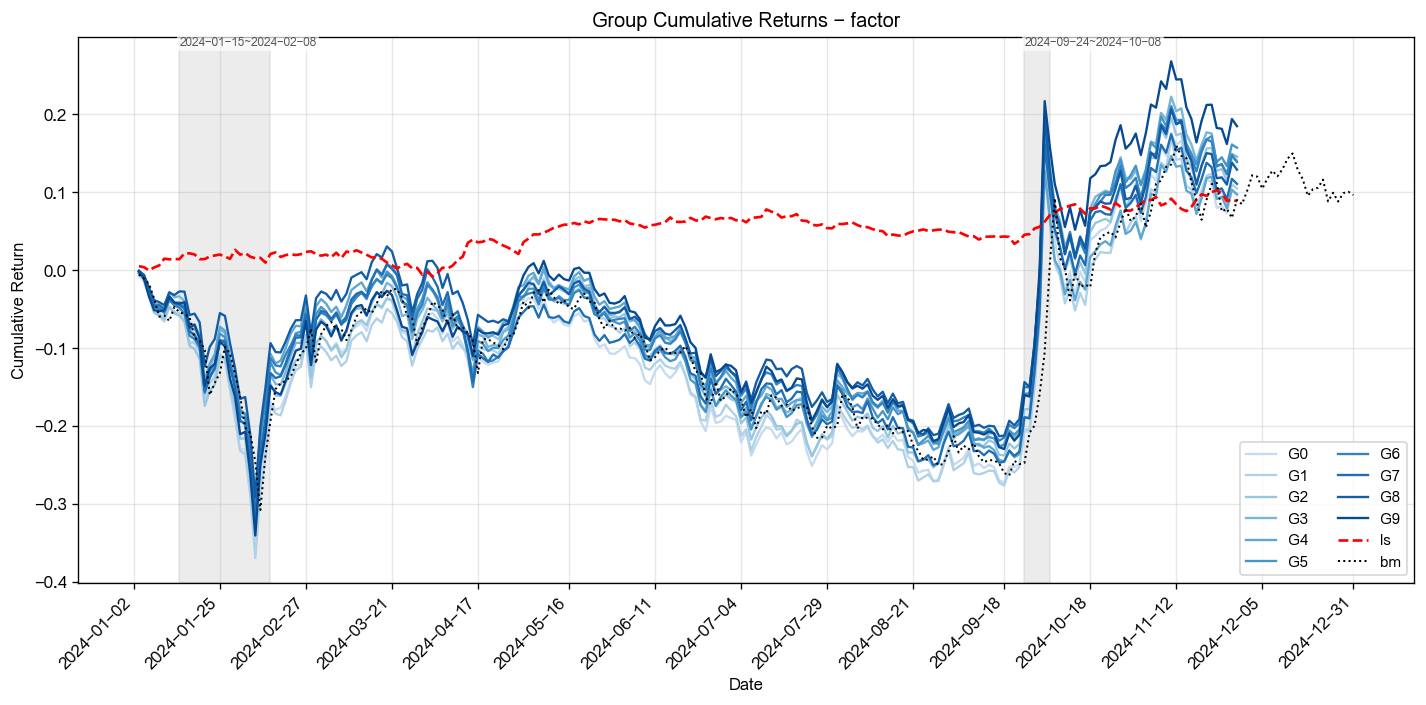
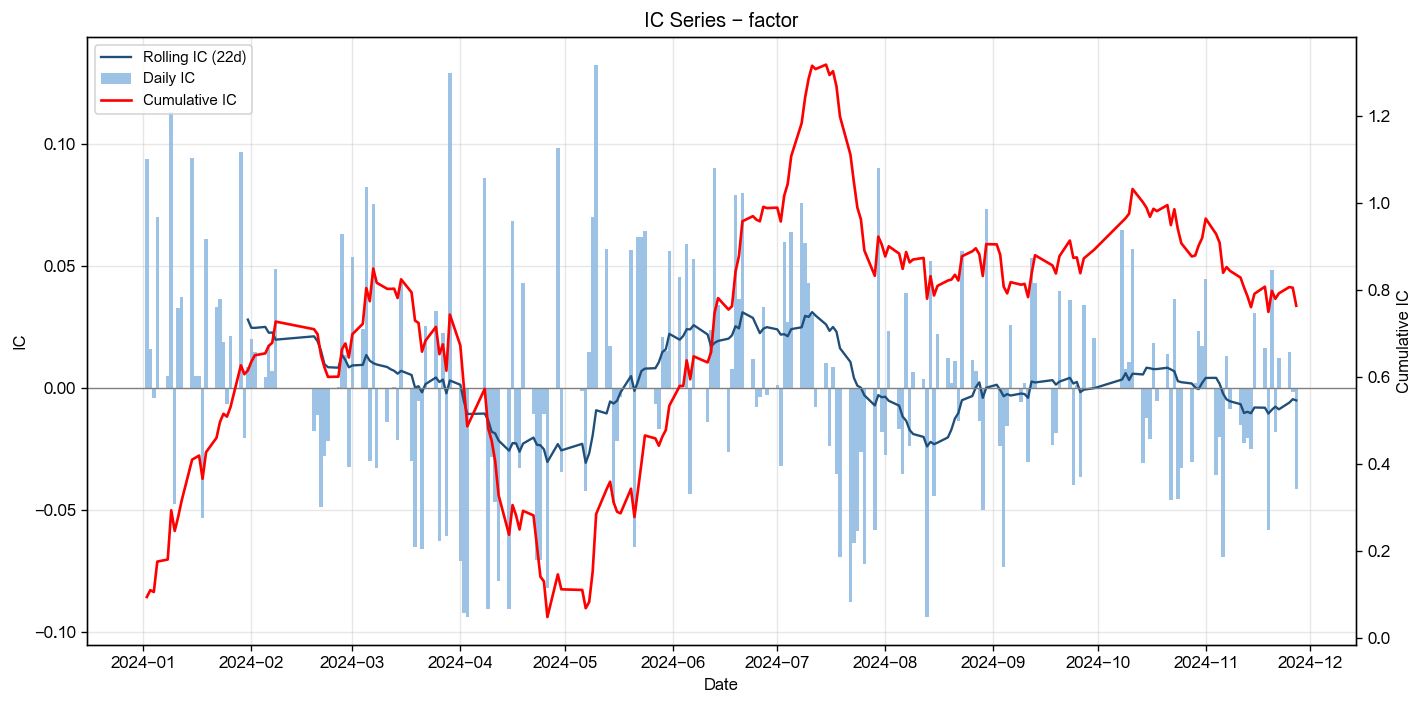
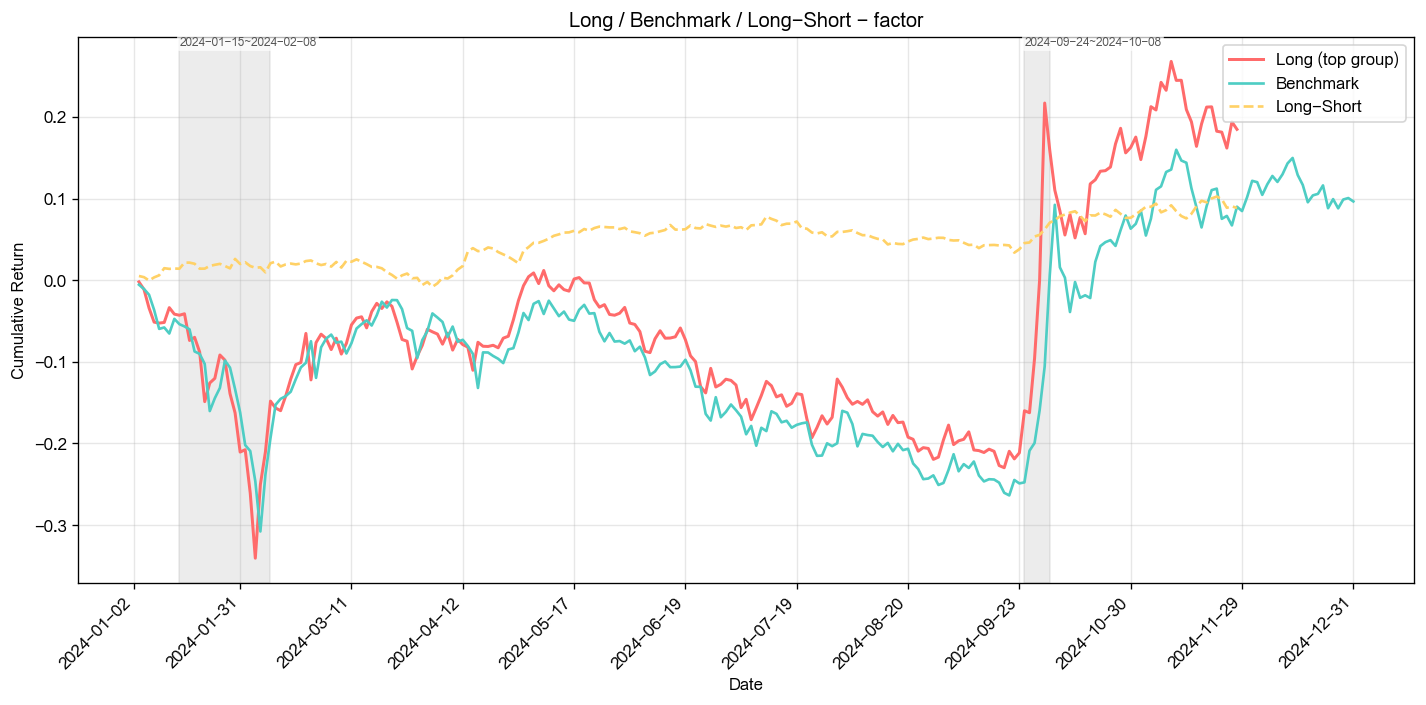
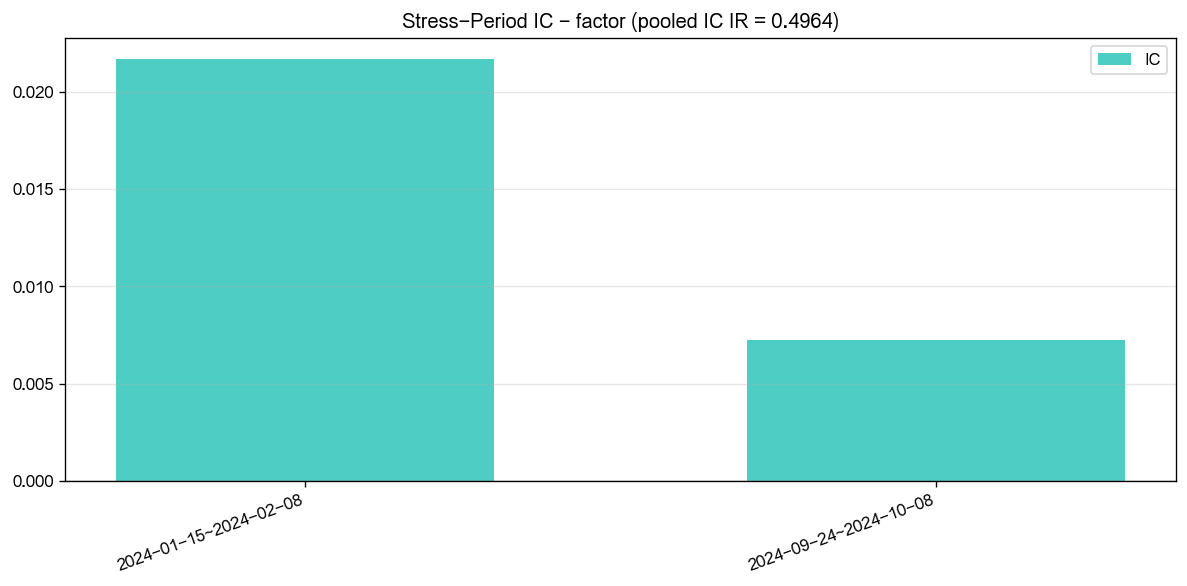
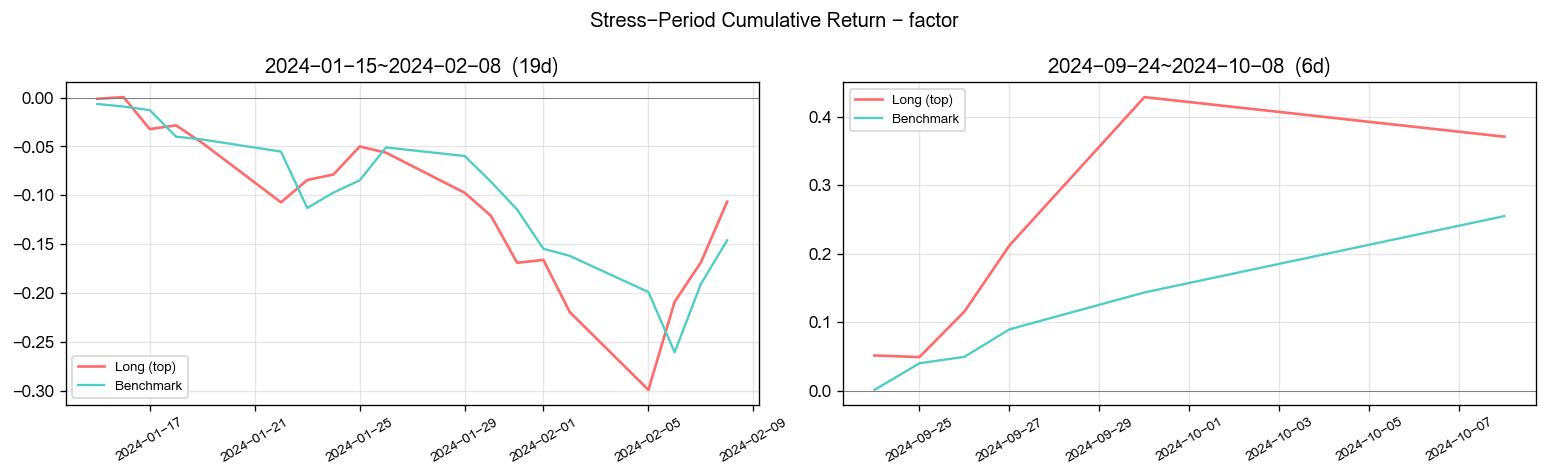

[2026-07-25 11:21:20] [info     ] ========== 因子池回归 ==========
[2026-07-25 11:21:21] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-25 11:21:21] [info     ] 获取收益率数据, 耗时: 1.7802 秒
[2026-07-25 11:21:24] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.9306 秒
[2026-07-25 11:21:24] [info     ] 统计 回归结果, 耗时: 0.0136 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9163,0.0443,0.0231,1.0000
2,amount,1.7043,0.0184,0.0108,1.0000
3,netflow_amount_rate_main,1.5308,0.0099,0.0065,1.0000
4,gross_profit_rate_ttm,1.5165,0.0070,0.0046,1.0000
5,netflow_amount_main,1.5085,0.0251,0.0167,1.0000
6,net_profit_rate_ttm,1.4601,0.0040,0.0027,0.8000
7,pb,1.4156,0.0096,0.0068,1.0000
8,bias_20,1.4137,0.0292,0.0206,0.9000
9,cci_14,1.3774,0.0338,0.0245,1.0000
10,ps_ttm,1.3326,0.0036,0.0027,0.9000

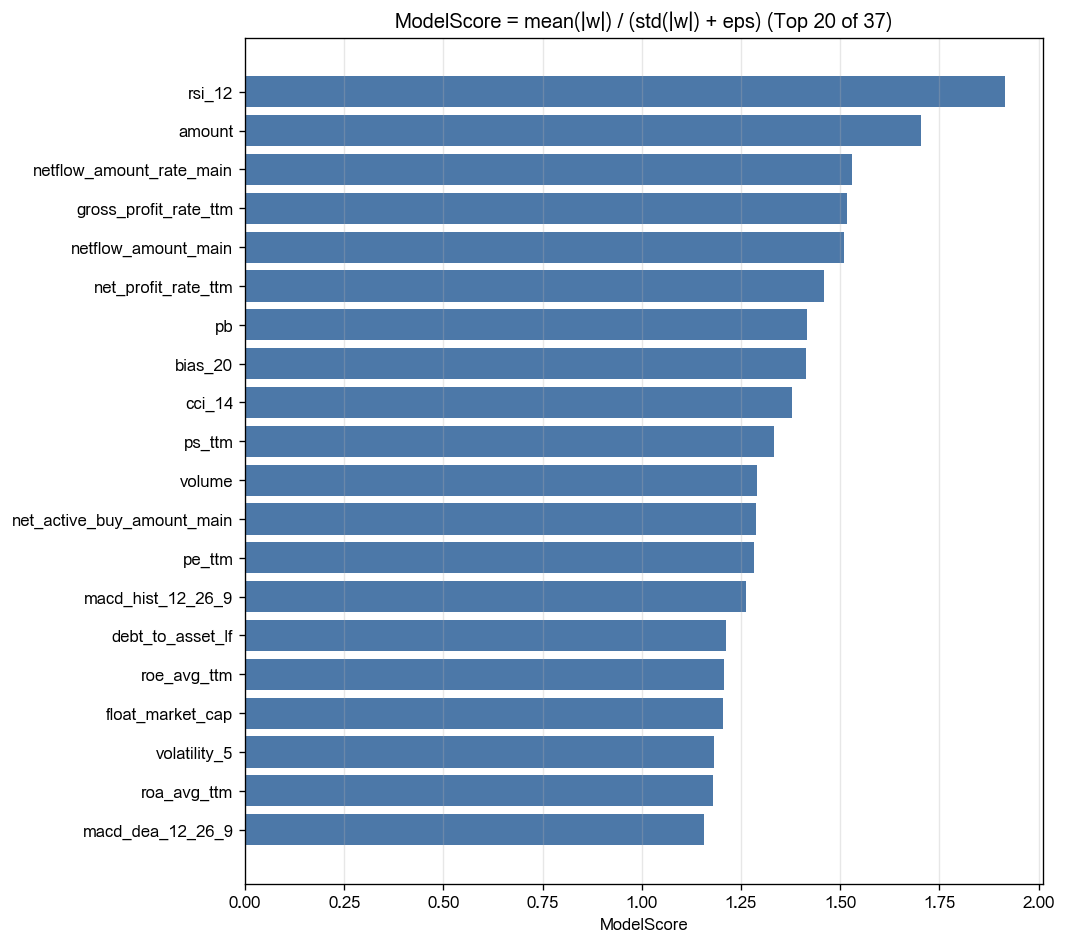
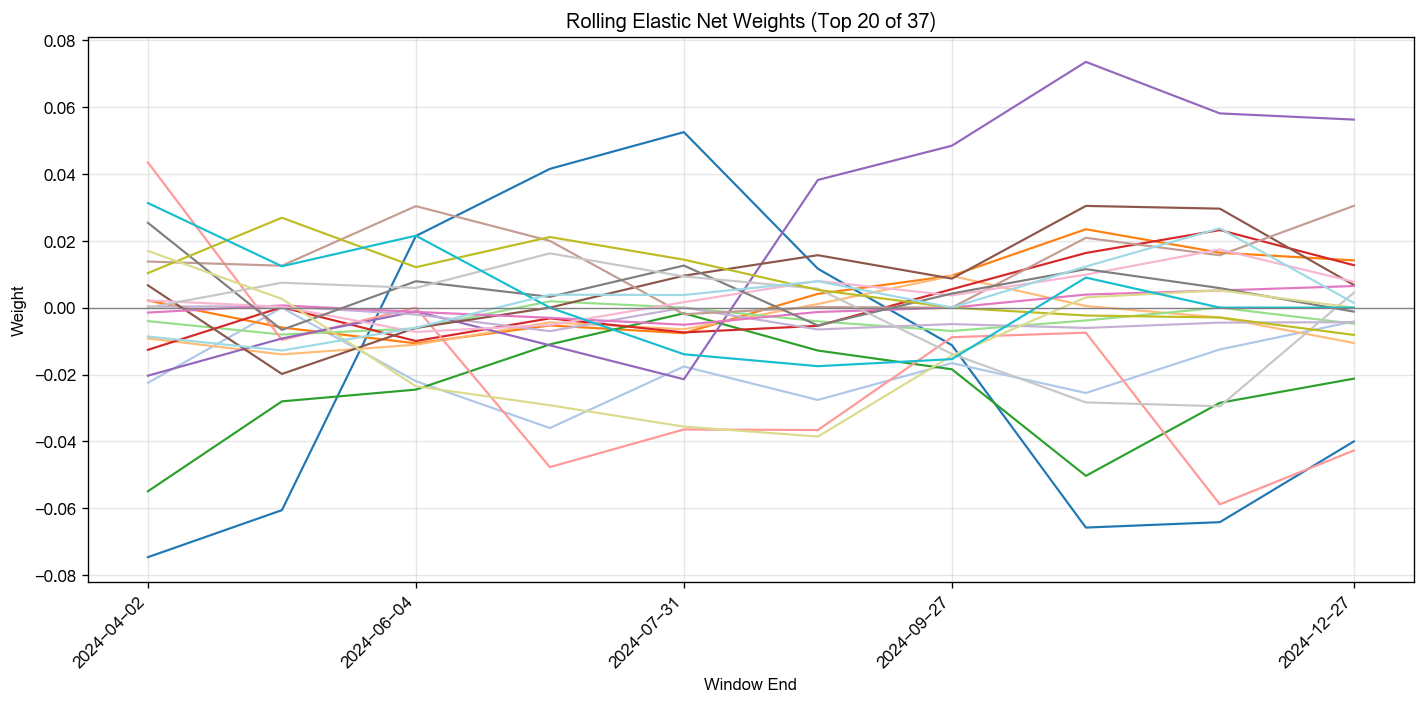
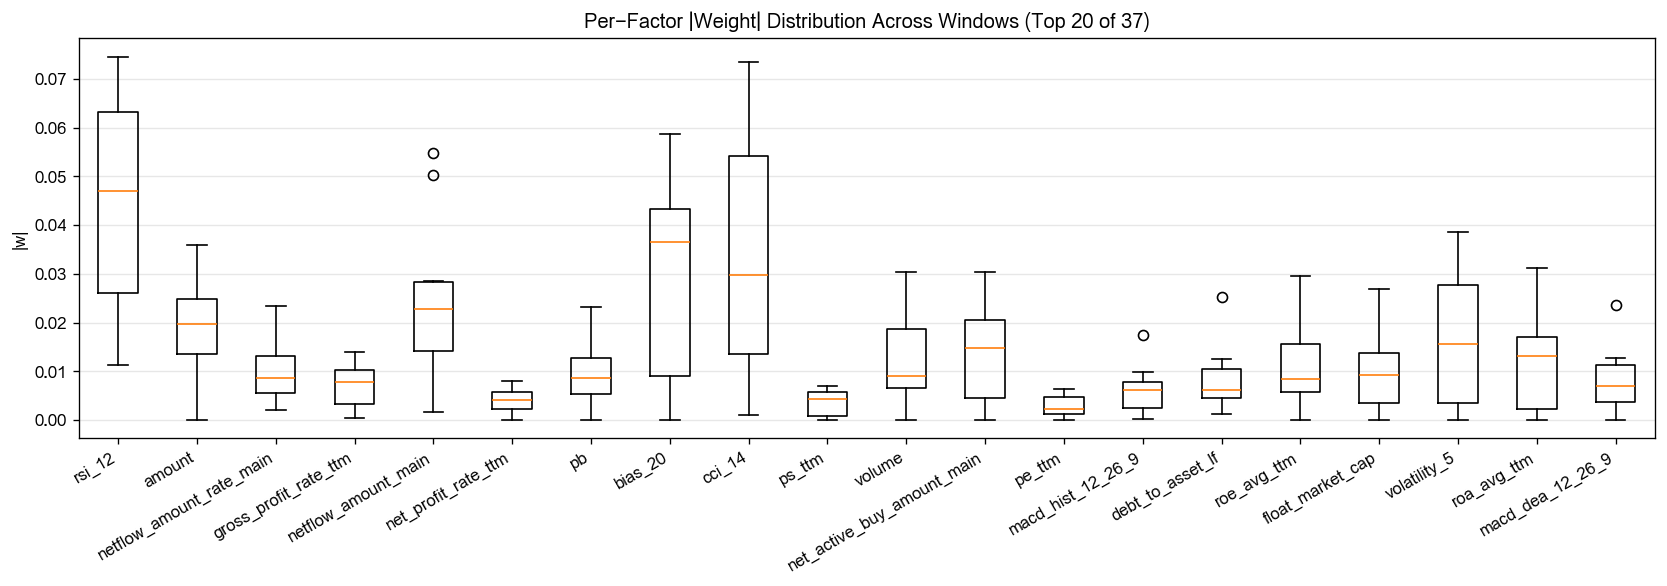
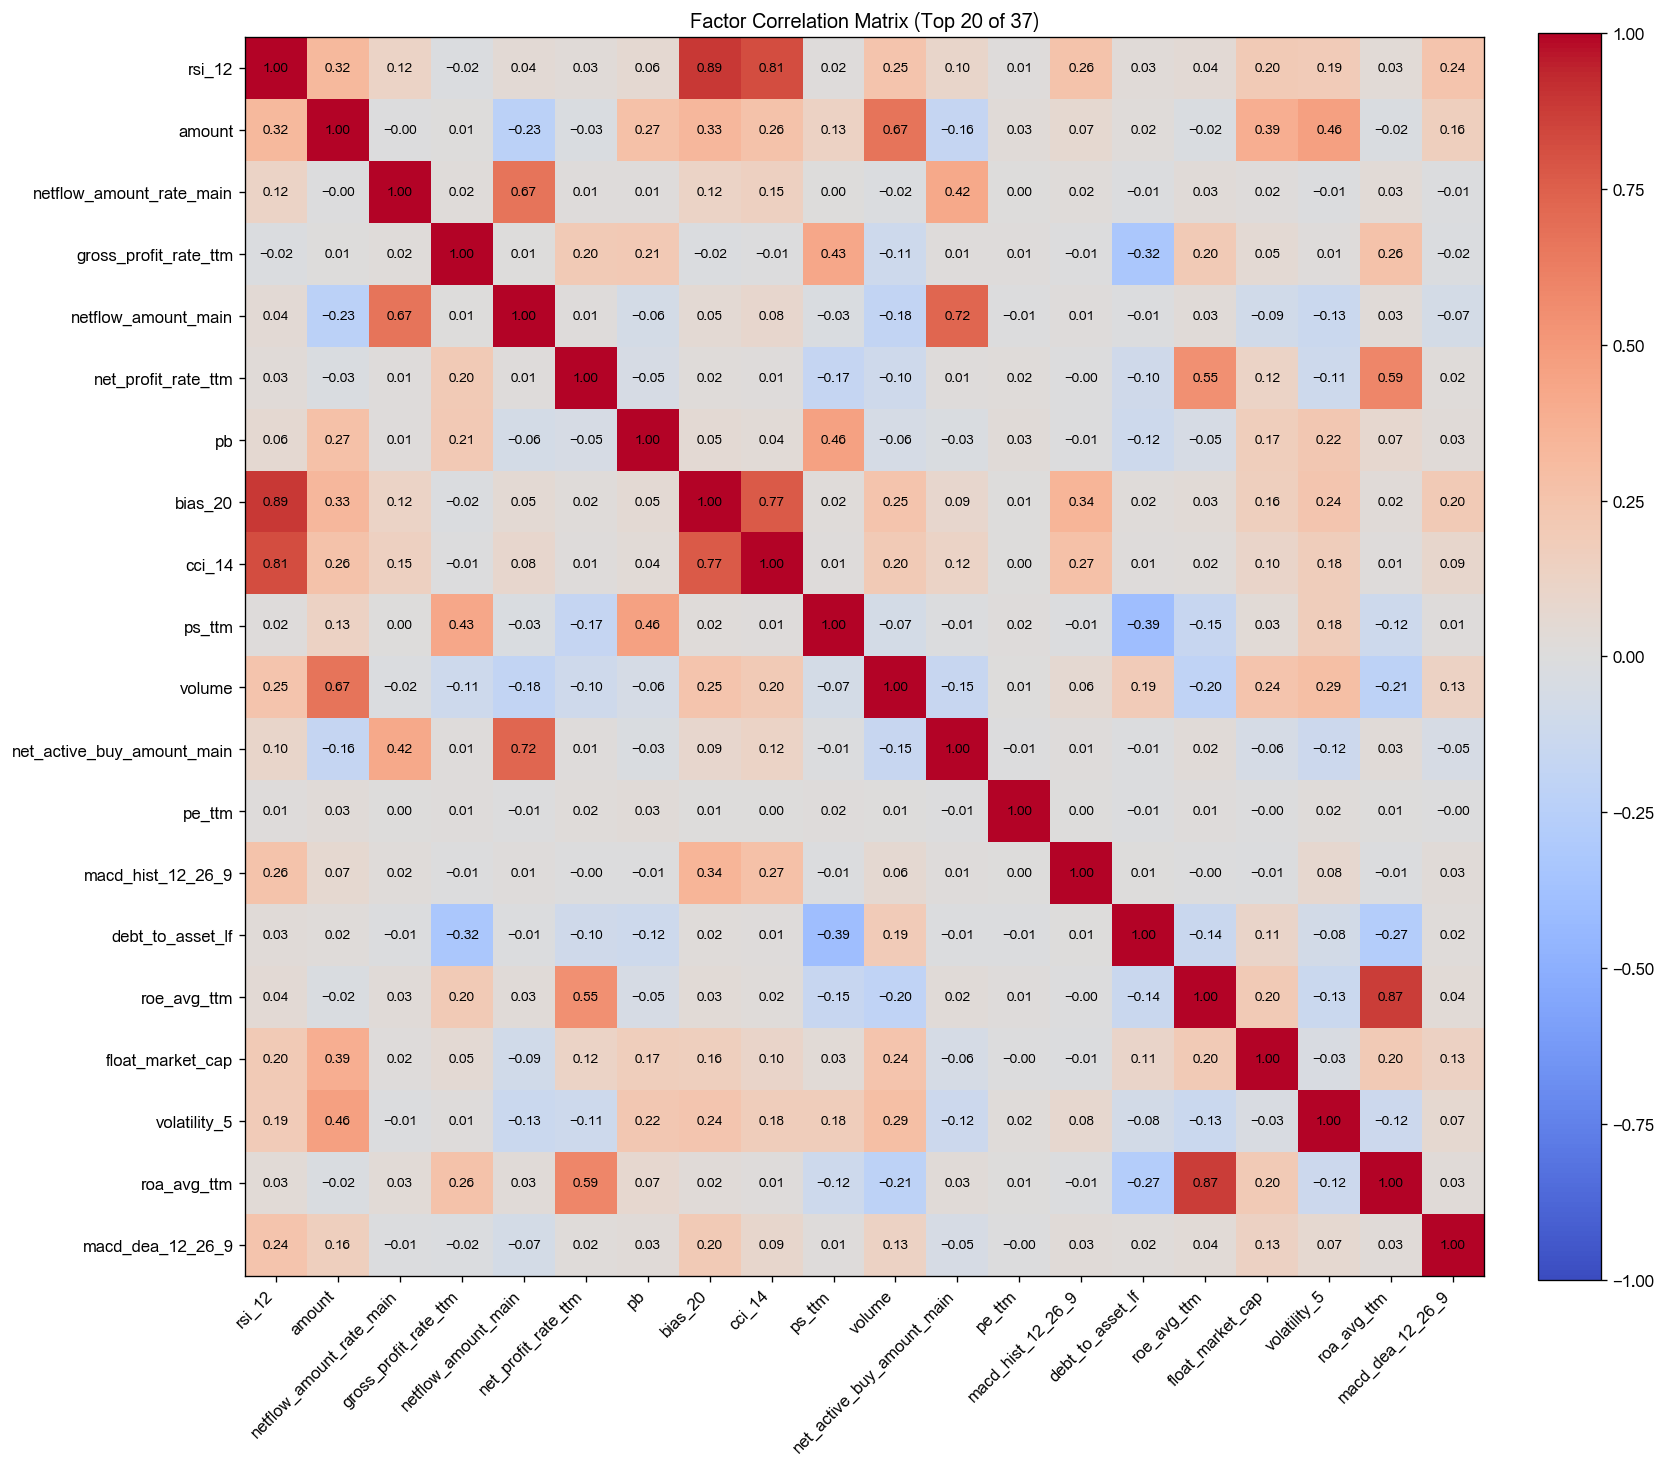

[2026-07-25 11:21:30] [warning  ] 返回的Outputs实例(size=35332629) 大于 64K, 将不会被缓存
[2026-07-25 11:21:30] [info     ] bigalpha_eval.v4 运行完成 [355.048s].


In [1]:
def main(datasources, start_date, end_date):
    """
    双口径盈利改善确认因子，并按最近公告距今天数进行指数衰减。

    平台会注入 datasources / start_date / end_date 并调用本函数。
    返回值必须且仅包含 date / instrument / factor 三列。
    """
    import numpy as np
    import pandas as pd
    import dai

    financial_table = datasources["financial"]

    # 向前读取两年，保证评估起点通常有足够的历史公告用于计算变化量。
    lookback_days = 730
    decay_days = 60.0
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=lookback_days)

    sql = f"""
    WITH profit_ttm AS (
        SELECT
            date,
            instrument,
            net_profit_to_parent_shareholders AS net_profit_ttm
        FROM {financial_table}
        WHERE category = 'ttm' AND shift = 0
    ),
    balance_lf AS (
        SELECT
            date,
            instrument,
            total_equity_to_parent_shareholders AS equity_lf,
            total_assets AS assets_lf
        FROM {financial_table}
        WHERE category = 'lf' AND shift = 0
    ),
    profitability_events AS (
        SELECT
            date,
            instrument,
            net_profit_ttm / equity_lf AS roe_ttm,
            net_profit_ttm / assets_lf AS roa_ttm
        FROM profit_ttm
        PRUNE JOIN balance_lf USING (date, instrument)
        WHERE equity_lf > 0 AND assets_lf > 0
    ),
    profitability_with_lag AS (
        SELECT
            date,
            instrument,
            roe_ttm,
            roa_ttm,
            LAG(roe_ttm, 1) OVER (
                PARTITION BY instrument ORDER BY date
            ) AS previous_roe_ttm,
            LAG(roa_ttm, 1) OVER (
                PARTITION BY instrument ORDER BY date
            ) AS previous_roa_ttm
        FROM profitability_events
    )
    SELECT
        date,
        instrument,
        roe_ttm - previous_roe_ttm AS delta_roe,
        roa_ttm - previous_roa_ttm AS delta_roa
    FROM profitability_with_lag
    WHERE previous_roe_ttm IS NOT NULL
      AND previous_roa_ttm IS NOT NULL
    ORDER BY date, instrument
    """

    events = dai.query(
        sql,
        filters={"date": [query_start_date, end_date]},
    ).df()

    events["date"] = pd.to_datetime(events["date"]).dt.normalize()
    for column in ["delta_roe", "delta_roa"]:
        events[column] = pd.to_numeric(events[column], errors="coerce")
        events[column] = events[column].replace([np.inf, -np.inf], np.nan)

    events = (
        events.dropna(subset=["delta_roe", "delta_roa"])
        .sort_values(["instrument", "date"])
        .drop_duplicates(["date", "instrument"], keep="last")
    )
    events["instrument"] = events["instrument"].astype(str)

    natural_dates = pd.date_range(
        start=query_start_date.normalize(),
        end=pd.to_datetime(end_date).normalize(),
        freq="D",
    )

    def reindex_and_fill(group):
        instrument = group.name
        event_data = group.set_index("date")[["delta_roe", "delta_roa"]].copy()
        # 在真实公告行记录公告日，随后与财务变化量一起仅向未来填充。
        event_data["announcement_date"] = event_data.index
        filled = event_data.reindex(natural_dates).ffill()
        filled["instrument"] = instrument
        return filled

    daily = (
        events.groupby("instrument", group_keys=False)
        .apply(reindex_and_fill)
        .reset_index()
        .rename(columns={"index": "date"})
    )
    daily["date"] = pd.to_datetime(daily["date"]).dt.normalize()
    daily["announcement_date"] = pd.to_datetime(daily["announcement_date"]).dt.normalize()
    daily["instrument"] = daily["instrument"].astype(str)

    # 股票池表给出实际交易日及当日真实的中证 1000 成分股。
    stock_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    stock_pool["date"] = pd.to_datetime(stock_pool["date"]).dt.normalize()
    stock_pool["instrument"] = stock_pool["instrument"].astype(str)
    stock_pool = stock_pool.drop_duplicates(["date", "instrument"])

    result = pd.merge(
        stock_pool,
        daily,
        how="left",
        on=["date", "instrument"],
        validate="one_to_one",
    )

    # 先合成盈利改善基础分，再按公告新鲜度衰减。
    result["rank_delta_roe"] = result.groupby("date")["delta_roe"].rank(
        method="average", pct=True
    )
    result["rank_delta_roa"] = result.groupby("date")["delta_roa"].rank(
        method="average", pct=True
    )
    result["base_factor"] = (
        result["rank_delta_roe"] + result["rank_delta_roa"] - 1.0
    )

    result["age_days"] = (
        result["date"] - result["announcement_date"]
    ).dt.days.clip(lower=0, upper=730)
    result["freshness"] = np.exp(-result["age_days"] / decay_days)
    result["factor"] = result["base_factor"] * result["freshness"]

    # 无足够历史公告时赋予中性值，保证覆盖度而不虚构正负观点。
    result["factor"] = (
        result["factor"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(float)
    )

    return result[["date", "instrument", "factor"]].sort_values(
        ["date", "instrument"]
    ).reset_index(drop=True)


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    datasources = {"financial": "bigalpha_2026_financial"}
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(f"计算盈利改善新鲜度因子：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    assert list(factor_data.columns) == ["date", "instrument", "factor"]
    assert not factor_data.duplicated(["date", "instrument"]).any()
    assert factor_data["factor"].notna().all()
    logger.info(
        "因子数据检查完成",
        rows=len(factor_data),
        trading_days=factor_data["date"].nunique(),
        instruments=factor_data["instrument"].nunique(),
        factor_min=float(factor_data["factor"].min()),
        factor_max=float(factor_data["factor"].max()),
        neutral_share=float((factor_data["factor"] == 0.0).mean()),
    )

    logger.info("读取比赛基础因子库")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
